In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn import metrics

In [ ]:
data = {
    'jam_belajar': [2, 3, 4, 5, 6, 7, 8, 9, 10, 12],
    'skor_ujian': [50, 58, 65, 70, 75, 82, 88, 92, 95, 99]
}

df = pd.DataFrame(data)
print(df)

   jam_belajar  skor_ujian
0            2          50
1            3          58
2            4          65
3            5          70
4            6          75
5            7          82
6            8          88
7            9          92
8           10          95
9           12          99


Pada praktikum ini, saya membuat data sendiri yang menggambarkan hubungan antara jam belajar dan skor ujian. Data terdiri dari 10 sampel dengan rentang waktu 2 jam hingga 12. Tema ini dipilih karena mudah dipahami secara logis semakin lama jam belajar, semakin tinggi skor ujian yg didapat.

In [ ]:
X = df[['jam_belajar']]
y = df['skor_ujian']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Data dibagi menjadi 80% data training (8 data) dan 20% data testing (2 data) menggunakan train_test_split. Model yang digunakan adalah Regresi Linear Sederhana dari library sklearn, dengan persamaan:

y = a + bx di mana y = skor_ujian, x = jam_belajar, a = intercept, b = koefisien/slope

In [ ]:
model = LinearRegression()
model.fit(X, y)

LinearRegression()

In [ ]:
print("Intercept (a):", model.intercept_)
print("Koefisien (b):", model.coef_[0])

Intercept (a): 43.85714285714286
Koefisien (b): 5.082251082251083


Berdasarkan hasil pemodelan, didapatkan persamaan regresi $y = 43.86 + 5.08x$, yang menunjukkan bahwa jika jam belajar bernilai nol, maka skor ujian diprediksi dimulai dari angka 43.86. Nilai koefisien sebesar 5.08 mengindikasikan bahwa setiap tambahan satu jam belajar akan meningkatkan skor ujian sebesar 5.08 poin, yang secara keseluruhan membuktikan adanya hubungan positif di mana semakin lama waktu belajar, maka semakin tinggi pula skor ujian yang diperoleh.

In [ ]:
y_pred = model.predict(X_test)

print("Data Testing:")
print(X_test)
print("Skor Asli:", y_test.values)
print("Skor Prediksi:", y_pred)

Data Testing:
   jam_belajar
8           10
1            3
Skor Asli: [95 58]
Skor Prediksi: [94.67965368 59.1038961 ]


Data Testing:
   jam_belajar
8           10
1            3
Skor Asli: [95 58]
Skor Prediksi: [94.67965368 59.1038961 ]
Hasil dan prediksi dari lean model dan data latih

In [ ]:
print("MAE:", metrics.mean_absolute_error(y_test, y_pred))
print("MSE:", metrics.mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(metrics.mean_squared_error(y_test, y_pred)))

MAE: 0.712121212121211
MSE: 0.6606041865782126
RMSE: 0.8127756065349234


Metrik dan Interpretasi:


* MAE : Rata-rata selisih antara
nilai prediksi dan nilai aktual
* MSE : Rata-rata kuadrat error lebih sensitif terhadap error besar
* RMSE :Akar dari MSE, satuannya sama dengan data asli.

Semakin kecil nilai MAE, MSE, dan RMSE, semakin akurat model dalam memprediksi penjualan.

In [ ]:
prediksi = model.predict([[12]])
print("Prediksi skor:", prediksi[0])

Prediksi skor: 104.84415584415585


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


Dari model yang di latih dan di uji data prediksi menunjukkan prediksi skornya 104.8 yang tidak masuk akal mengikuti tren data.

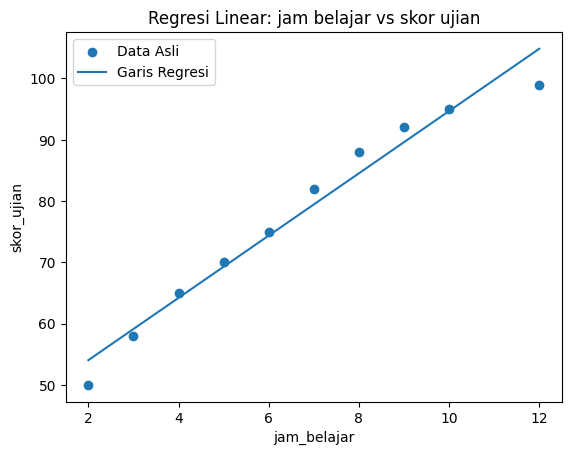

In [ ]:
plt.scatter(X, y, label="Data Asli")
plt.plot(X, model.predict(X), label="Garis Regresi")
plt.xlabel("jam_belajar")
plt.ylabel("skor_ujian")
plt.title("Regresi Linear: jam belajar vs skor ujian")
plt.legend()
plt.show()